In [3]:
from google.colab import files
uploaded = files.upload()



Saving tennis_stats.csv to tennis_stats.csv


In [5]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


                 Player  Year  FirstServe  FirstServePointsWon  \
0           Pedro Sousa  2016        0.88                 0.50   
1       Roman Safiullin  2017        0.84                 0.62   
2           Pedro Sousa  2017        0.83                 0.60   
3   Rogerio Dutra Silva  2010        0.83                 0.64   
4  Daniel Gimeno-Traver  2017        0.81                 0.54   

   FirstServeReturnPointsWon  SecondServePointsWon  \
0                       0.38                  0.50   
1                       0.26                  0.33   
2                       0.28                  0.53   
3                       0.34                  0.59   
4                       0.00                  0.33   

   SecondServeReturnPointsWon  Aces  BreakPointsConverted  BreakPointsFaced  \
0                        0.39     0                  0.14                 7   
1                        0.07     7                  0.00                 7   
2                        0.44     2      

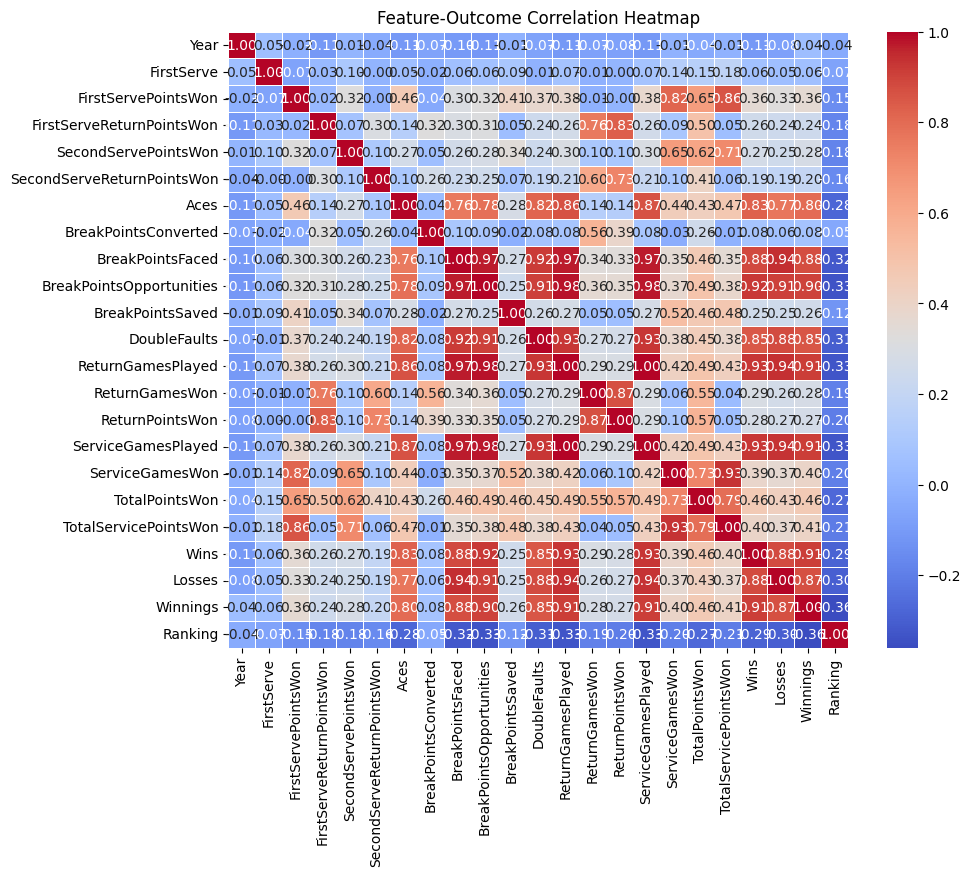

In [8]:
# Loading the dataset
import pandas as pd

df = pd.read_csv("tennis_stats.csv")

# Display first few rows
print(df.head())

# Display column names
print("\nColumn Names:")
print(df.columns)

# Checking for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Describing the dataset
print("\nDataset Summary:")
print(df.describe())

# Correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature-Outcome Correlation Heatmap")
plt.show()


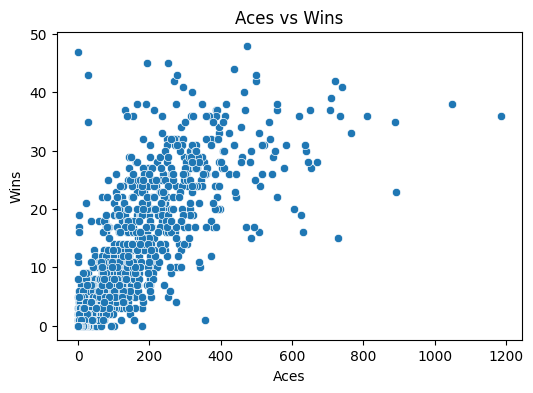

<ipython-input-9-6853649b6fa3>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["Ranking"], y=df["ServiceGamesWon"], palette="Blues")


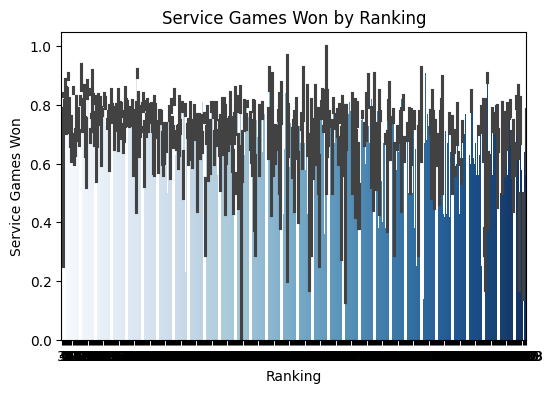

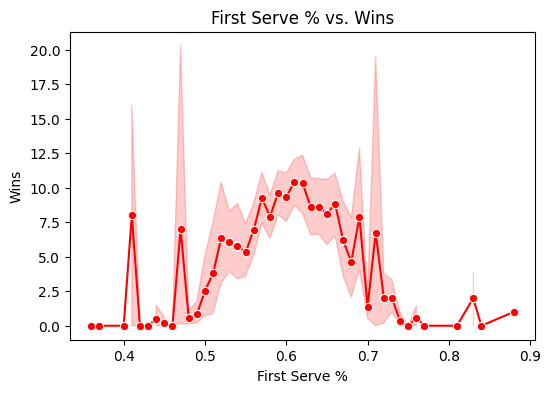

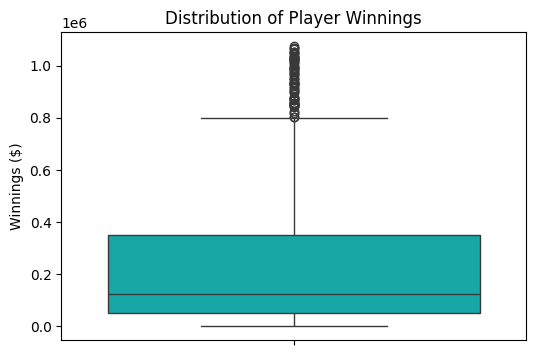

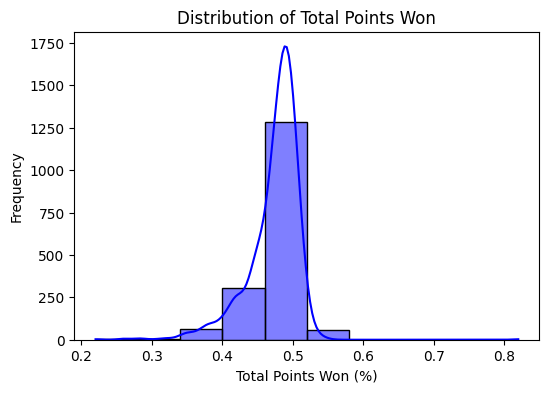

In [9]:
# Scatter Plot: Aces vs. Wins
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["Aces"], y=df["Wins"])
plt.xlabel("Aces")
plt.ylabel("Wins")
plt.title("Aces vs Wins")
plt.show()

# Bar Plot: Service Games Won by Ranking
plt.figure(figsize=(6, 4))
sns.barplot(x=df["Ranking"], y=df["ServiceGamesWon"], palette="Blues")
plt.xlabel("Ranking")
plt.ylabel("Service Games Won")
plt.title("Service Games Won by Ranking")
plt.show()

# Line Plot: First Serve % vs. Wins
plt.figure(figsize=(6, 4))
sns.lineplot(x=df["FirstServe"], y=df["Wins"], marker="o", color="r")
plt.xlabel("First Serve %")
plt.ylabel("Wins")
plt.title("First Serve % vs. Wins")
plt.show()

# Box Plot: Winnings Distribution
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Winnings"], color="c")
plt.ylabel("Winnings ($)")
plt.title("Distribution of Player Winnings")
plt.show()

# Histogram: Total Points Won
plt.figure(figsize=(6, 4))
sns.histplot(df["TotalPointsWon"], bins=10, kde=True, color="b")
plt.xlabel("Total Points Won (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Points Won")
plt.show()



Single Feature Linear Regression Model: BreakPointsOpportunities -> Winnings
Mean Squared Error (MSE): 12619219445.274075
R² Score: 0.7865551696389493


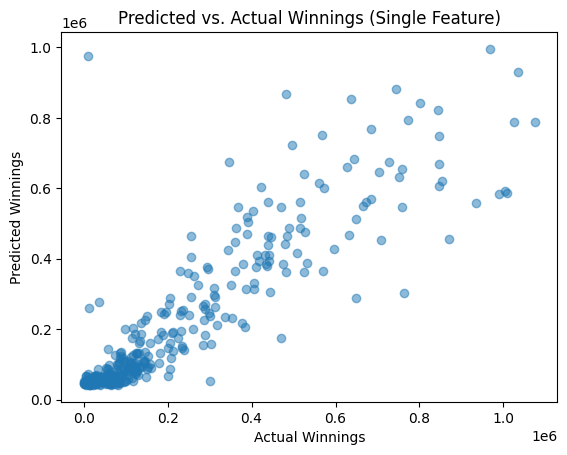

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Select feature and target variable
X = df[['BreakPointsOpportunities']]  # Feature
y = df[['Winnings']]  # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"\nSingle Feature Linear Regression Model: BreakPointsOpportunities -> Winnings")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")

# Plot actual vs predicted values
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Winnings")
plt.ylabel("Predicted Winnings")
plt.title("Predicted vs. Actual Winnings (Single Feature)")
plt.show()



Two-Feature Linear Regression Model: BreakPointsOpportunities & FirstServeReturnPointsWon -> Winnings
Mean Squared Error (MSE): 12456944318.20527
R² Score: 0.7892999342513113


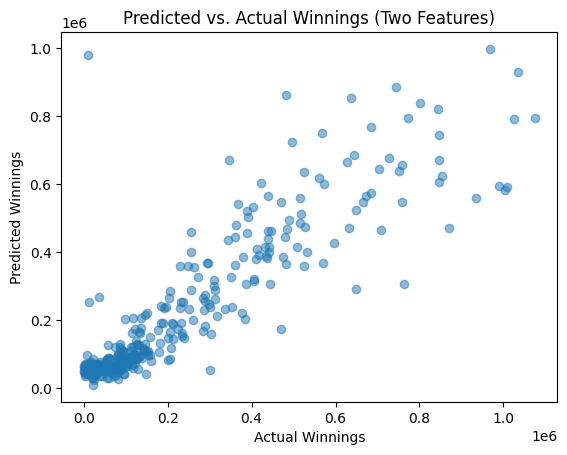

In [11]:
# Selecting two features for prediction
X = df[['BreakPointsOpportunities', 'FirstServeReturnPointsWon']]
y = df[['Winnings']]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluating performance
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Printing results
print(f"\nTwo-Feature Linear Regression Model: BreakPointsOpportunities & FirstServeReturnPointsWon -> Winnings")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")

# Plotting actual vs predicted winnings
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Winnings")
plt.ylabel("Predicted Winnings")
plt.title("Predicted vs. Actual Winnings (Two Features)")
plt.show()



Multiple Feature Linear Regression Model: Multiple Features -> Winnings
Mean Squared Error (MSE): 10239044220.288769
R² Score: 0.8268140857573171


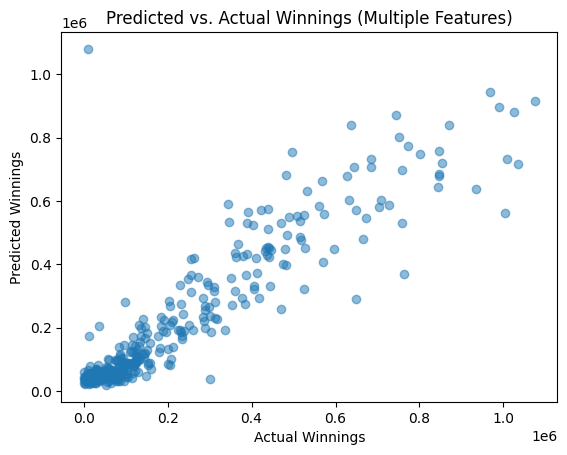

In [12]:
# Selecting multiple features
X = df[['FirstServe', 'FirstServePointsWon', 'FirstServeReturnPointsWon',
        'SecondServePointsWon', 'SecondServeReturnPointsWon', 'Aces',
        'BreakPointsConverted', 'BreakPointsFaced', 'BreakPointsOpportunities',
        'BreakPointsSaved', 'DoubleFaults', 'ReturnGamesPlayed', 'ReturnGamesWon',
        'ReturnPointsWon', 'ServiceGamesPlayed', 'ServiceGamesWon',
        'TotalPointsWon', 'TotalServicePointsWon']]
y = df[['Winnings']]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate performance
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"\nMultiple Feature Linear Regression Model: Multiple Features -> Winnings")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")

# Plot actual vs predicted winnings
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Winnings")
plt.ylabel("Predicted Winnings")
plt.title("Predicted vs. Actual Winnings (Multiple Features)")
plt.show()
